In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
print(df.shape)

(200, 5)


In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 0


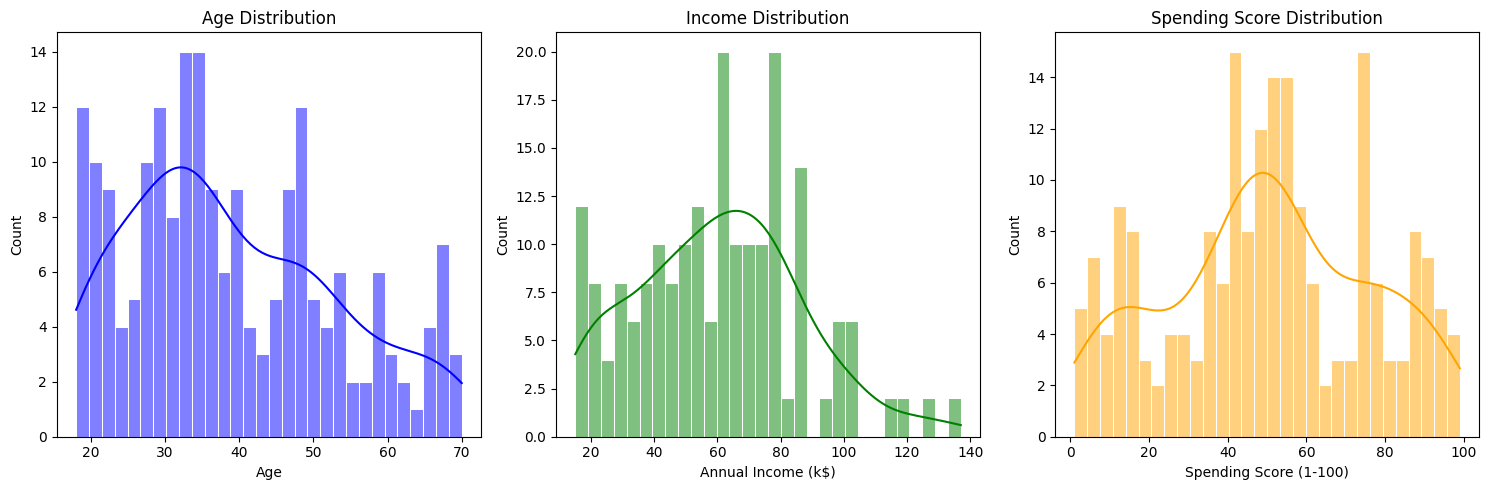

In [7]:
# Distribution plots (numerical)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

sns.histplot(df["Age"], bins=30, color='blue', edgecolor='white', kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["Annual Income (k$)"], bins=30, color='green', edgecolor='white', kde=True, ax=axes[1])
axes[1].set_title("Income Distribution")

sns.histplot(df["Spending Score (1-100)"], bins=30, color='orange', edgecolor='white', kde=True, ax=axes[2])
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()

C:\Users\03cri\AppData\Local\Temp\ipykernel_36080\158440332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette="pastel")


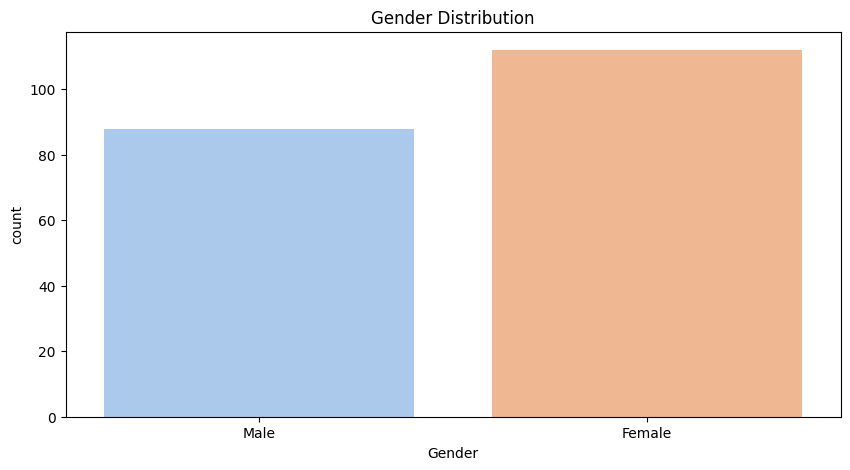

In [8]:
# Distribution plots (categorical)
plt.figure(figsize=(10, 5))
sns.countplot(x="Gender", data=df, palette="pastel")
plt.title("Gender Distribution")
plt.show()

In [9]:
df["Encoded_Gender"] = df["Gender"].map({'Male': 0, 'Female': 1})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Encoded_Gender
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [10]:
dropping = df.drop(columns=["CustomerID", "Gender"], inplace=True)
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Encoded_Gender
0,19,15,39,0
1,21,15,81,0
2,20,16,6,1
3,23,16,77,1
4,31,17,40,1


In [13]:
from sklearn.preprocessing import StandardScaler

X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape of scaled features:", X_scaled.shape)

Shape of scaled features: (200, 3)


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [16]:
#Run KMeans for multiple K values
inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "K": list(K),
    "Inertia": inertia,
    "Silhouette Score": sil_scores
})
print(results)

    K     Inertia  Silhouette Score
0   2  389.386189          0.335472
1   3  295.212246          0.357793
2   4  205.225147          0.403958
3   5  168.247580          0.416643
4   6  133.868421          0.428417
5   7  117.011555          0.417232
6   8  103.873292          0.408207
7   9   93.092891          0.417693
8  10   82.385154          0.406554


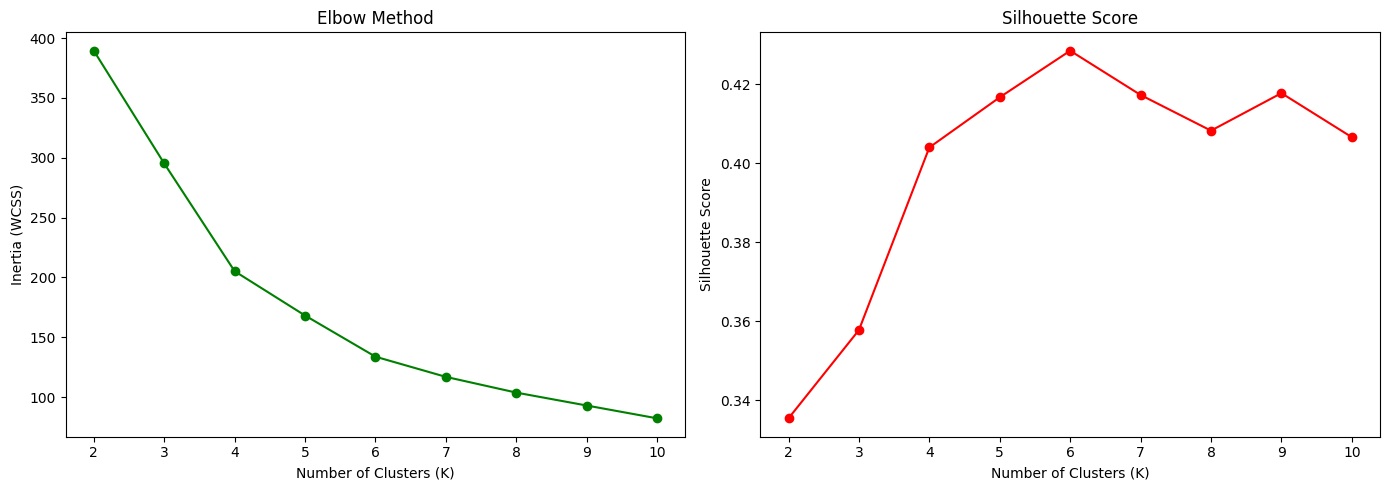

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Elbow Method
ax[0].plot(K, inertia, marker='o', color='green')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Inertia (WCSS)")

# Silhouette Score
ax[1].plot(K, sil_scores, marker='o', color='red')
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [19]:
best_k = results.loc[
    results["Silhouette Score"].idxmax(),
    "K"
]

best_score = results["Silhouette Score"].max()

print(f"Best K: {best_k}")
print(f"Highest Silhouette Score: {best_score:.4f}")


Best K: 6
Highest Silhouette Score: 0.4284


In [21]:
# Train Final K-Means Model
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(X_scaled)

# Add Cluster Labels
df["Cluster"] = clusters
print("\nFirst 5 Rows with Cluster Labels:")
print(df.head())


First 5 Rows with Cluster Labels:
   Age  Annual Income (k$)  Spending Score (1-100)  Encoded_Gender  Cluster
0   19                  15                      39               0        4
1   21                  15                      81               0        4
2   20                  16                       6               1        5
3   23                  16                      77               1        4
4   31                  17                      40               1        5


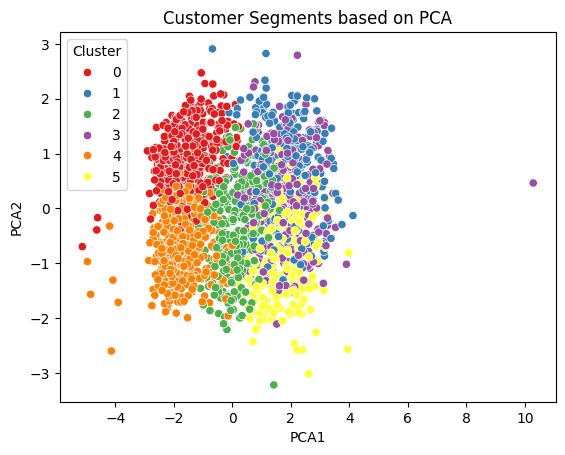

In [ ]:
sns.scatterplot(x="PCA1", y="PCA2", hue = "Cluster", data = df, palette = "Set1")
plt.title("Customer Segments based on PCA")
plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster")[features].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,55.024145,35360.100410,106.979879,2.152918,3.303823,6.350101,75.772636
1,70.416667,73071.628763,1166.110000,4.413333,8.020000,2.556667,55.693333
2,60.067485,52035.404389,586.957055,6.751534,5.917178,6.751534,51.567485
3,46.232258,78955.980456,1318.867742,4.383871,8.432258,2.529032,52.487097
4,51.518868,33095.599620,93.703774,1.971698,3.141509,6.556604,25.001887
5,58.425993,66650.731884,1097.927798,7.765343,9.797834,5.509025,33.592058


In [ ]:
import joblib

#save model and scaler
joblib. dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']